In [ ]:
import pandas as pd
from datetime import datetime
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr


# Load the dataset
file_path = 'dataset_estudiantes_parentales.csv'

# Attempt to read the file, using 'latin1' encoding as a fallback for potential encoding issues
df = pd.read_csv(file_path, sep=";", encoding='latin1')

# Intentar cargar el archivo con utf-8
#df = pd.read_csv('dataset_estudiantes_parentales.csv', sep=";", encoding='utf-8', errors='replace')


# Display the first few rows to visualize the data
print("First few rows of the dataset:")
print(df.head())

First few rows of the dataset:
   id_estudiante       dni f_nacimiento     genero  \
0              1   8798342    6/05/1980  masculino   
1              2  41197560   20/06/1981  masculino   
2              3  42299195   10/06/1983  masculino   
3              4  42475319    2/07/1984  masculino   
4              5  42542298    2/07/1984   femenino   

                            carrera    codigo  num_hijos edad_hijos  \
0  MEDICINA VETERINARIA Y ZOOTECNÍA   10165.0        2.0      3 y 5   
1                   MEDICINA HUMANA  102305.0        2.0      4,  9   
2                  INGENIERÍA CIVIL  230108.0        1.0         13   
3                   MEDICINA HUMANA   21070.0        2.0     16; 12   
4                 EDUCACIÓN INICIAL  217605.0        3.0  18, 16, 5   

    vive_con          ocupacion  ... planificacion_tiempo_hijoyacademico  \
0     Pareja  Estudia y trabaja  ...                             Siempre   
1     Pareja  Estudia y trabaja  ...                        Casi 

In [ ]:
# Check for columns with null values
print("\nColumns with null values:")
print(df.isnull().sum())



Columns with null values:
id_estudiante                           0
dni                                     0
f_nacimiento                            3
genero                                  0
carrera                                 3
codigo                                  3
num_hijos                               0
edad_hijos                              0
vive_con                                1
ocupacion                               0
apoyo_padres                            0
gastos_con_pareja                       0
tipo_seguro                             0
momento_parental                        0
tiempo_libre                            0
cambio_dinamica_parental               26
cambio_vida_social                     26
comunicación_familiares                26
relacion_coparental_buena              26
evito_descuidar_hogar                  26
pausa_estudios_cuidado_hijo            26
considero_pausa_estudios               26
considero_dejar_estudiar               26
pendien

In [ ]:
# Display the number of records
print(f"\nNumero de Registros antes de eliminar nulos: {len(df)}")

# Remove rows with null values
df_cleaned = df.dropna()

# Display the number of records
print(f"\nNumero de Registros despues de eliminar nulos: {len(df_cleaned)}")

'''
# Drop rows where 'carrera' is numeric or empty
if 'carrera' in df_cleaned.columns:
    df_cleaned = df_cleaned[df_cleaned['carrera'].apply(lambda x: isinstance(x, str) and not x.isnumeric() and x.strip() != "")]
'''

# Display the number of records
print(f"\nNumero de Registros despues de eliminar carreras que tengan numeros: {len(df)}")

# Drop the 'edad_hijos' column if it exists
if 'edad_hijos' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['edad_hijos'])

# Drop the 'codigo' column if it exists
if 'codigo' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['codigo'])


# Drop the 'dni' column if it exists
if 'dni' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['dni'])

# Drop the 'id_estudiante' column if it exists
if 'id_estudiante' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['id_estudiante'])

# Calculate the 'edad' column based on the 'f_nacimiento' column
if 'f_nacimiento' in df_cleaned.columns:
    df_cleaned['edad'] = df_cleaned['f_nacimiento'].apply(lambda x: datetime.now().year - pd.to_datetime(x).year)

# Drop the 'f_nacimiento' column if it exists
if 'f_nacimiento' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['f_nacimiento'])

# Drop the 'tiempo_libre' column if it exists
# La columna, tiene datos muy variados, es textual la descripcion
if 'tiempo_libre' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['tiempo_libre'])


Numero de Registros antes de eliminar nulos: 236

Numero de Registros despues de eliminar nulos: 206

Numero de Registros despues de eliminar carreras que tengan numeros: 236


<ipython-input-3-e74d349fb18b>:38: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_cleaned['edad'] = df_cleaned['f_nacimiento'].apply(lambda x: datetime.now().year - pd.to_datetime(x).year)


In [ ]:
'''
# La Data tiene muchos erroes en cuanto al numero de hijos

# Correct invalid data in the 'num_hijos' column if it exists
if 'num_hijos' in df_cleaned.columns:
    # Replace non-numeric values with NaN
    df_cleaned['num_hijos'] = pd.to_numeric(df_cleaned['num_hijos'], errors='coerce')

    # Replace NaN values with the median value
    median_hijos = df_cleaned['num_hijos'].median()
    df_cleaned['num_hijos'].fillna(median_hijos, inplace=True)

    # Identify outliers using the IQR method
    Q1 = df_cleaned['num_hijos'].quantile(0.25)
    Q3 = df_cleaned['num_hijos'].quantile(0.75)
    IQR = Q3 - Q1

    # Filter out outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned['num_hijos'] = df_cleaned['num_hijos'].apply(lambda x: x if lower_bound <= x <= upper_bound else median_hijos)

    # Ensure all values are integers
    df_cleaned['num_hijos'] = df_cleaned['num_hijos'].round().astype(int)


# Save the cleaned and processed dataset
cleaned_file_path = './dataset_numhijos_corregidos.csv'
df_cleaned.to_csv(cleaned_file_path, index=False)


# Display frequency table for 'num_hijos'
print("\nFrequency table for 'num_hijos':")
freq_table = df_cleaned['num_hijos'].value_counts().sort_index()
print(freq_table)


# Plot frequency distribution
plt.figure(figsize=(8, 6))
freq_table.plot(kind='bar', color='skyblue')
plt.title("Frequency Distribution of 'num_hijos'")
plt.xlabel("Number of Children")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.show()


'''
# Los datos de la cantidad de hijos, no es acorde a las edades que se ponen y la fecha de nacimiento del estudiante padre

# Drop the 'num_hijos' column if it exists
if 'num_hijos' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['num_hijos'])

'''

# Display frequency table
print("\nFrequency table':")
freq_table = df_cleaned['carrera'].value_counts().sort_index()
print(freq_table)

# Plot frequency distribution
plt.figure(figsize=(8, 6))
freq_table.plot(kind='bar', color='skyblue')
plt.title("Frequency Distribution ")
plt.xlabel("Carreras")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.show()
'''

'''
# NO ES RELEVANTE

# Adjust 'vive_con' column based on 'genero'
if 'vive_con' in df_cleaned.columns and 'genero' in df_cleaned.columns:
    def ajustar_vive_con(row):
        if row['vive_con'] == 'Solo (a )':
            return 'Solo' if row['genero'] == 'masculino' else 'Sola'
        return row['vive_con']

    df_cleaned['vive_con'] = df_cleaned.apply(ajustar_vive_con, axis=1)

'''

# Ajustar la columna 'carrera' para corregir valores no válidos
if 'carrera' in df_cleaned.columns:
    # Identificar valores no válidos (valores numéricos en este caso)
    invalid_carreras = df_cleaned['carrera'].apply(lambda x: str(x).isdigit())

    # Calcular frecuencia relativa de categorías válidas para imputación ponderada
    valid_carreras = df_cleaned.loc[~invalid_carreras, 'carrera']
    frequencies = valid_carreras.value_counts(normalize=True)

    # Reemplazar valores inválidos de forma aleatoria ponderada
    num_invalid = invalid_carreras.sum()
    df_cleaned.loc[invalid_carreras, 'carrera'] = np.random.choice(
        frequencies.index,
        size=num_invalid,
        p=frequencies.values
    )



In [ ]:
df_cleaned.head()



,genero,carrera,vive_con,ocupacion,apoyo_padres,gastos_con_pareja,tipo_seguro,momento_parental,cambio_dinamica_parental,cambio_vida_social,...,apruebo_asignaturas,ampliacion_conocimiento,impacto_sobrecarga,presento_tareas,asistencia_puntual,abandono_clases,expongo_seguro,impacto_rendimiento,satisfaccion_rendimiento,edad
0,masculino,MEDICINA VETERINARIA Y ZOOTECNÍA,Pareja,Estudia y trabaja,No,No,Seguro Integral de Salud (SIS),Durante la universidad,Casi siempre,Siempre,...,A veces,Siempre,Casi siempre,Casi siempre,A veces,Nunca,Casi siempre,Siempre,Siempre,44
1,masculino,MEDICINA HUMANA,Pareja,Estudia y trabaja,No,Si,Essalud,Durante la universidad,Casi siempre,Siempre,...,A veces,Siempre,Casi siempre,Siempre,Casi siempre,Casi siempre,Casi siempre,Casi siempre,Casi siempre,43
2,masculino,INGENIERÍA CIVIL,Solo (a ),Solamente estudia,No,Si,Seguro Integral de Salud (SIS),Antes de ingresar a la universidad,Nunca,Nunca,...,Casi siempre,Siempre,Nunca,Siempre,Siempre,Nunca,Siempre,Nunca,Siempre,41
3,masculino,MEDICINA HUMANA,Pareja,Estudia y trabaja,No,Si,Seguro Integral de Salud (SIS),Durante la universidad,Siempre,Siempre,...,A veces,Siempre,Siempre,Siempre,Siempre,Nunca,Casi siempre,Casi siempre,Siempre,40
4,femenino,EDUCACIÓN INICIAL,Solo (a ),Estudia y trabaja,No,No,Seguro Integral de Salud (SIS),Antes de ingresar a la universidad,A veces,A veces,...,Casi siempre,Casi siempre,A veces,Siempre,Casi siempre,Nunca,Casi siempre,A veces,Casi siempre,40


In [ ]:
from google.colab import files

# Guardar el archivo limpio
df_cleaned.to_csv('dataset_cleaned.csv', sep=';', index=False, encoding="latin1")

# Descargar el archivo
#files.download('dataset_cleaned.csv')


In [ ]:
# Display the number of rows and columns in the cleaned dataframe
print(f"Number of rows in df_cleaned: {df_cleaned.shape[0]}")
print(f"Number of columns in df_cleaned: {df_cleaned.shape[1]}")

Number of rows in df_cleaned: 206
Number of columns in df_cleaned: 39


In [ ]:
df_cleaned.describe()

,edad
count,206.000000
mean,27.063107
std,6.132751
min,17.000000
25%,23.000000
50%,26.000000
75%,31.000000
max,47.000000


**Clustermap plots a matrix dataset as a hierarchically-clustered heatmap.**



In [ ]:
sns.clustermap(df_cleaned.corr(), cmap='viridis', col_cluster=True);


ValueError: could not convert string to float: 'masculino'

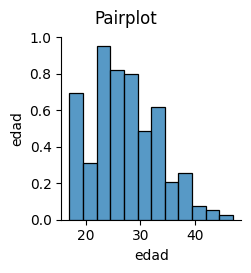

In [ ]:
sns.pairplot(df_cleaned);
plt.suptitle('Pairplot', y=1.05);

In [ ]:
'''
# Encode categorical variables using LabelEncoder
categorical_columns = df_cleaned.select_dtypes(include=['object']).columns
print("\nCategorical columns identified for encoding:")
print(categorical_columns)

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))
    label_encoders[col] = le

# Scale numerical columns excluding specific ones
numerical_columns = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
excluded_columns = ['id_estudiante', 'dni']
numerical_columns = [col for col in numerical_columns if col not in excluded_columns]
scaler = StandardScaler()
df_cleaned[numerical_columns] = scaler.fit_transform(df_cleaned[numerical_columns])
'''

'''

# Identify categorical columns
categorical_columns = df_cleaned.select_dtypes(include=['object']).columns
print("\nCategorical columns identified:")
print(categorical_columns)

# Apply MCA (Multiple Correspondence Analysis) for dimensionality reduction of categorical data
print("\nApplying MCA for dimensionality reduction on categorical data:")
mca = MCA(n_components=10, random_state=42)
mca_result = mca.fit_transform(df_cleaned[categorical_columns])
#explained_inertia = mca.explained_inertia_
#print("Explained variance by MCA components:", explained_inertia)

# Combine MCA results with numerical data
numerical_columns = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
numerical_data = df_cleaned[numerical_columns].reset_index(drop=True)
mca_data = pd.DataFrame(mca_result, columns=[f'MCA_{i+1}' for i in range(mca_result.shape[1])])
combined_data = pd.concat([numerical_data, mca_data], axis=1)

# Scale combined data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(combined_data)
'''

'''
# Define ordinal variables and their Likert scale mapping
ordinal_columns = [
    'cambio_dinamica_parental', 'cambio_vida_social', 'comunicación_familiares',
    'relacion_coparental_buena', 'evito_descuidar_hogar', 'pausa_estudios_cuidado_hijo',
    'considero_pausa_estudios', 'considero_dejar_estudiar', 'pendiente_hijo',
    'dedido_tiempo_tareas', 'apoyo_familiar_hijo', 'coparentalidad_cuidado',
    'esfuerzo_academico', 'procupo_menor_hijo', 'satisfaccion_resultados_academicos',
    'planifico_dia', 'planifico_tiempo_hijo', 'planifico_tiempo_tareas',
    'prioridades_diarias', 'cumplo_actividades_diarias',
    'planificacion_tiempo_hijoyacademico', 'apruebo_asignaturas',
    'ampliacion_conocimiento', 'impacto_sobrecarga', 'presento_tareas',
    'asistencia_puntual', 'abandono_clases', 'expongo_seguro',
    'impacto_rendimiento', 'satisfaccion_rendimiento'
]

likert_scale = {
    'Nunca': 0,
    'A veces': 1,
    'Casi siempre': 2,
    'Siempre': 3
}

# Map Likert scale to ordinal variables
for column in ordinal_columns:
    if column in df_cleaned.columns:
        df_cleaned[column] = df_cleaned[column].map(likert_scale)
'''


# Encode remaining categorical variables
encoders = {}
for column in df_cleaned.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_cleaned[column] = le.fit_transform(df_cleaned[column])
    encoders[column] = le

# Apply SelectKBest for feature selection
print("\nApplying SelectKBest for feature selection")
X_selected = SelectKBest(score_func=chi2, k=10).fit_transform(df_cleaned, df_cleaned.index)
selected_features = SelectKBest(score_func=chi2, k=10).fit(df_cleaned, df_cleaned.index).get_support(indices=True)
selected_columns = df_cleaned.columns[selected_features]
print(f"Count Selected features: {len(list(selected_columns))}")
print(f"Selected features: {list(selected_columns)}")


'''
# Reduce the dataframe to selected features
selected_columns = list(selected_columns)  # Ensure it's a list for appending
if 'genero' in df_cleaned.columns and 'genero' not in selected_columns:
    selected_columns.append('genero')  # Add 'genero' column if not included
'''

df_cleaned = df_cleaned[selected_columns]

'''
print(f"Count Selected features included genero: {len(list(selected_columns))}")
print(f"Selected features: {list(selected_columns)}")
'''

# Guardar el archivo
df_cleaned.to_csv('dataset_encoded.csv', sep=';', index=False, encoding="latin1")
df_cleaned.head()

# Descargar el archivo
#files.download('dataset_encoded.csv')




Applying SelectKBest for feature selection
Count Selected features: 10
Selected features: ['carrera', 'cambio_dinamica_parental', 'comunicación_familiares', 'pausa_estudios_cuidado_hijo', 'considero_pausa_estudios', 'apoyo_familiar_hijo', 'apruebo_asignaturas', 'impacto_sobrecarga', 'impacto_rendimiento', 'edad']


,carrera,cambio_dinamica_parental,comunicación_familiares,pausa_estudios_cuidado_hijo,considero_pausa_estudios,apoyo_familiar_hijo,apruebo_asignaturas,impacto_sobrecarga,impacto_rendimiento,edad
0,35,1,0,1,1,2,0,1,3,44
1,34,1,0,3,3,0,0,1,1,43
2,23,2,3,2,2,0,1,2,2,41
3,34,3,3,3,3,3,0,3,1,40
4,13,0,2,2,0,2,1,0,0,40


In [ ]:

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)

df_scaled = pd.DataFrame(scaled_data, columns=df_cleaned.columns.tolist())

# Guardar el archivo
df_scaled.to_csv('dataset_scaled.csv', sep=';', index=False, encoding="latin1")
df_scaled.head()

# Descargar el archivo
#files.download('dataset_scaled.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

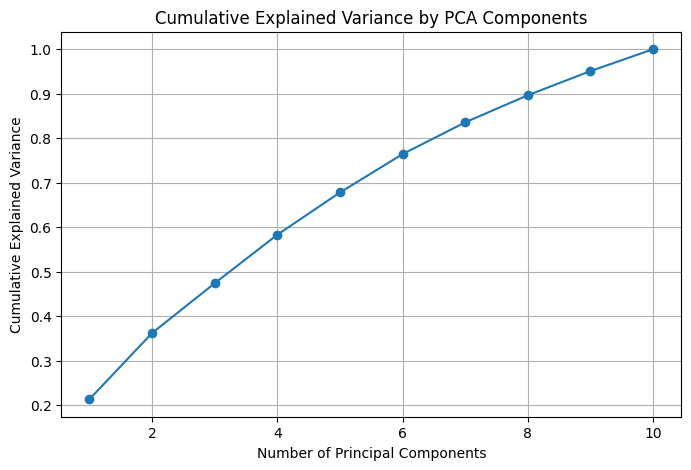

In [ ]:


# Apply PCA for dimensionality reduction
pca = PCA()
pca_result = pca.fit_transform(scaled_data)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance ratio
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [ ]:
# Determine the optimal number of components (95% variance)
num_components = np.argmax(explained_variance >= 0.95) + 1

print(f"Numero de componentes:{num_components}")

# Reduce dimensionality to the optimal number of components
pca_optimal = PCA(n_components=num_components)
data_reduced = pca_optimal.fit_transform(scaled_data)

Numero de componentes:9


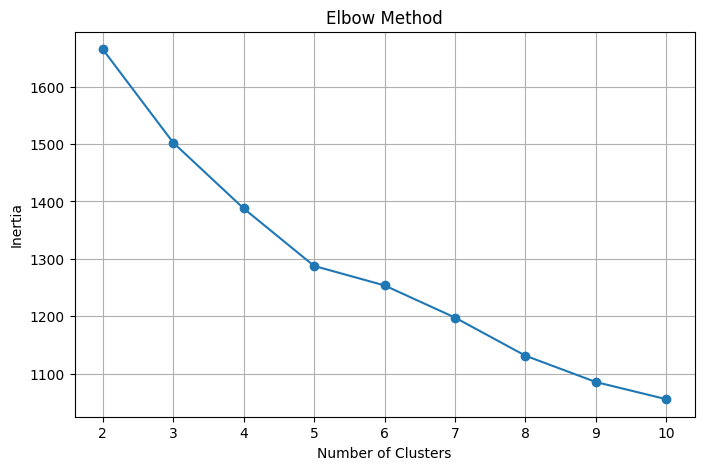

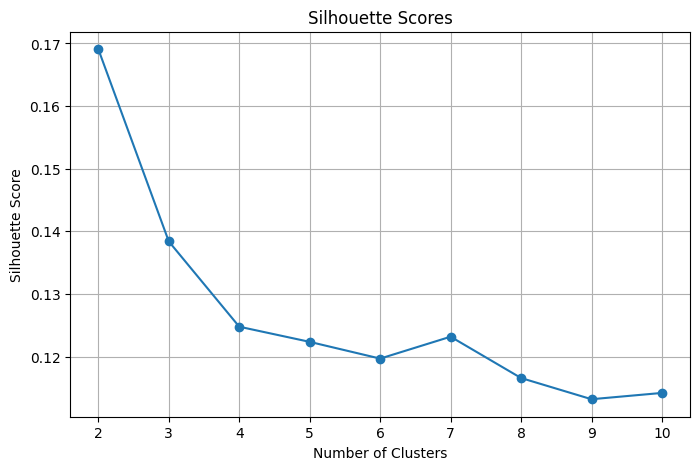

In [ ]:
# Elbow Method to determine optimal number of clusters
inertia = []
silhouette_scores = []
clusters_range = range(2, 11)

for k in clusters_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_reduced)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(data_reduced, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(clusters_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(clusters_range, silhouette_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [ ]:
# Choose the optimal number of clusters (based on visual inspection, e.g., k=4)
optimal_clusters = 2

# Apply K-Means clustering with optimal clusters
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans_clusters = kmeans.fit_predict(data_reduced)

# Evaluate K-Means Clustering
kmeans_silhouette = silhouette_score(data_reduced, kmeans_clusters)
kmeans_davies_bouldin = davies_bouldin_score(data_reduced, kmeans_clusters)
kmeans_calinski_harabasz = calinski_harabasz_score(data_reduced, kmeans_clusters)

print("\nK-Means Clustering Evaluation:")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {kmeans_calinski_harabasz:.4f}")





K-Means Clustering Evaluation:
Silhouette Score: 0.1691
Davies-Bouldin Index: 2.0276
Calinski-Harabasz Index: 35.9528


In [ ]:


# Apply DBSCAN clustering
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(data_reduced)

# Evaluate DBSCAN Clustering (if applicable)
if len(set(dbscan_clusters)) > 1:
    dbscan_silhouette = silhouette_score(data_reduced, dbscan_clusters)
    dbscan_davies_bouldin = davies_bouldin_score(data_reduced, dbscan_clusters)
    dbscan_calinski_harabasz = calinski_harabasz_score(data_reduced, dbscan_clusters)
    print("\nDBSCAN Clustering Evaluation:")
    print(f"Silhouette Score: {dbscan_silhouette:.4f}")
    print(f"Davies-Bouldin Index: {dbscan_davies_bouldin:.4f}")
    print(f"Calinski-Harabasz Index: {dbscan_calinski_harabasz:.4f}")
else:
    print("\nDBSCAN Clustering Evaluation: Not applicable (single cluster or noise only)")





DBSCAN Clustering Evaluation:
Silhouette Score: -0.1805
Davies-Bouldin Index: 1.7131
Calinski-Harabasz Index: 4.2331


In [ ]:



# Apply Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=optimal_clusters)
agglo_clusters = agglo.fit_predict(data_reduced)

# Evaluate Agglomerative Clustering
agglo_silhouette = silhouette_score(data_reduced, agglo_clusters)
agglo_davies_bouldin = davies_bouldin_score(data_reduced, agglo_clusters)
agglo_calinski_harabasz = calinski_harabasz_score(data_reduced, agglo_clusters)

print("\nAgglomerative Clustering Evaluation:")
print(f"Silhouette Score: {agglo_silhouette:.4f}")
print(f"Davies-Bouldin Index: {agglo_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {agglo_calinski_harabasz:.4f}")




Agglomerative Clustering Evaluation:
Silhouette Score: 0.1548
Davies-Bouldin Index: 2.1127
Calinski-Harabasz Index: 29.9797


In [ ]:
'''
# Evaluate clustering results
kmeans_silhouette = silhouette_score(data_reduced, kmeans_clusters)
dbscan_silhouette = silhouette_score(data_reduced, dbscan_clusters) if len(set(dbscan_clusters)) > 1 else 'N/A'
agglo_silhouette = silhouette_score(data_reduced, agglo_clusters)

# Add the clusters to the original df_cleaned
df_cleaned['KMeans_Cluster'] = kmeans_clusters
df_cleaned['DBSCAN_Cluster'] = dbscan_clusters
df_cleaned['Agglo_Cluster'] = agglo_clusters

'''

"\n# Evaluate clustering results\nkmeans_silhouette = silhouette_score(data_reduced, kmeans_clusters)\ndbscan_silhouette = silhouette_score(data_reduced, dbscan_clusters) if len(set(dbscan_clusters)) > 1 else 'N/A'\nagglo_silhouette = silhouette_score(data_reduced, agglo_clusters)\n\n# Add the clusters to the original df_cleaned\ndf_cleaned['KMeans_Cluster'] = kmeans_clusters\ndf_cleaned['DBSCAN_Cluster'] = dbscan_clusters\ndf_cleaned['Agglo_Cluster'] = agglo_clusters\n\n"

In [ ]:
# Analyze cluster characteristics
cluster_data = pd.DataFrame(data_reduced, columns=[f"PCA_{i+1}" for i in range(data_reduced.shape[1])])
cluster_data['KMeans_Cluster'] = kmeans_clusters
cluster_data['Agglomerative_Cluster'] = agglo_clusters
cluster_data['DBSCAN_Cluster'] = dbscan_clusters

# Map cluster labels to the original data
df_cleaned['KMeans_Cluster'] = kmeans_clusters
df_cleaned['Agglomerative_Cluster'] = agglo_clusters
df_cleaned['DBSCAN_Cluster'] = dbscan_clusters

# Compute descriptive statistics for original variables by K-Means clusters
kmeans_cluster_summary = df_cleaned.groupby('KMeans_Cluster').mean()
print("\nDescriptive Statistics for Original Variables by K-Means Clusters:")
print(kmeans_cluster_summary)

# Compute descriptive statistics for original variables by Agglomerative clusters
agglo_cluster_summary = df_cleaned.groupby('Agglomerative_Cluster').mean()
print("\nDescriptive Statistics for Original Variables by Agglomerative Clusters:")
print(agglo_cluster_summary)

# Compute descriptive statistics for original variables by DBSCAN clusters
if len(set(dbscan_clusters)) > 1:
    dbscan_cluster_summary = df_cleaned.groupby('DBSCAN_Cluster').mean()
    print("\nDescriptive Statistics for Original Variables by DBSCAN Clusters:")
    print(dbscan_cluster_summary)




Descriptive Statistics for Original Variables by K-Means Clusters:
                  carrera  cambio_dinamica_parental  comunicación_familiares  \
KMeans_Cluster                                                                 
0               21.947368                  1.434211                 0.980263   
1               19.111111                  1.944444                 1.685185   

                pausa_estudios_cuidado_hijo  considero_pausa_estudios  \
KMeans_Cluster                                                          
0                                  0.934211                  0.782895   
1                                  1.833333                  2.111111   

                apoyo_familiar_hijo  apruebo_asignaturas  impacto_sobrecarga  \
KMeans_Cluster                                                                 
0                          0.828947             1.052632            0.631579   
1                          1.611111             2.277778            1.907407  

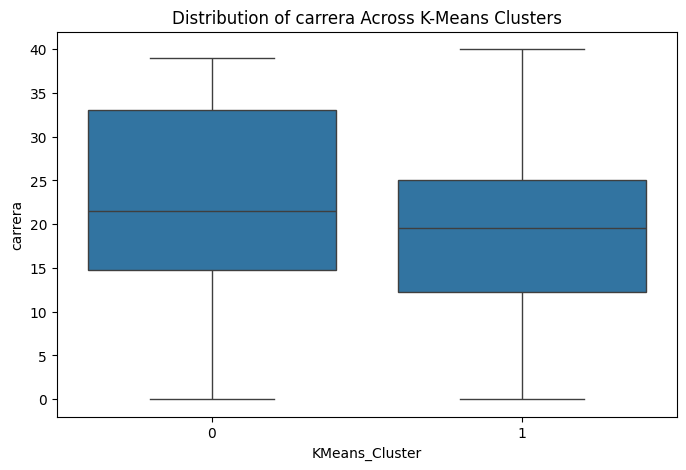

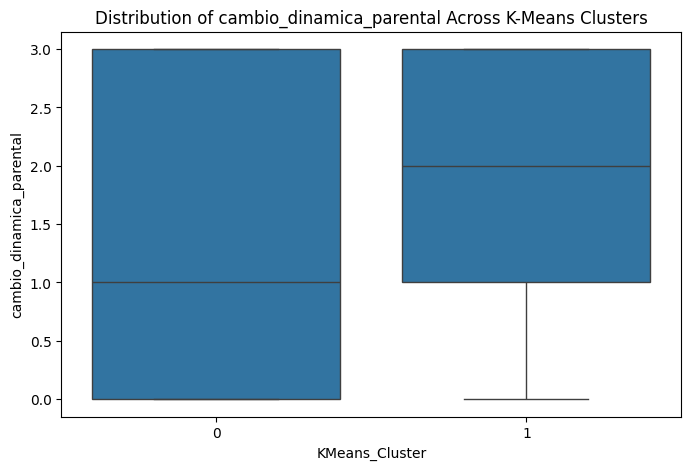

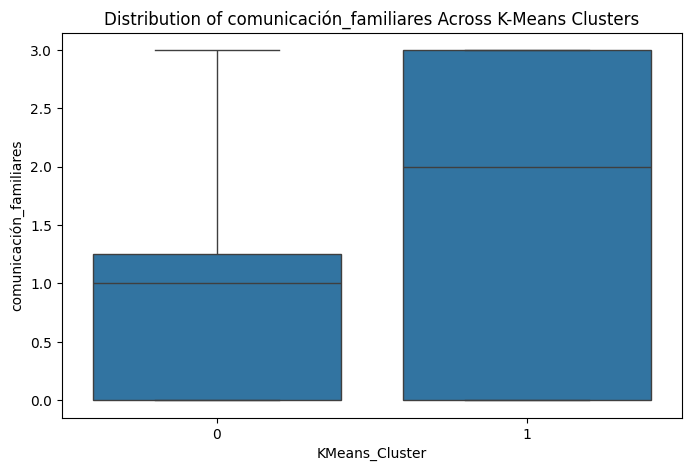

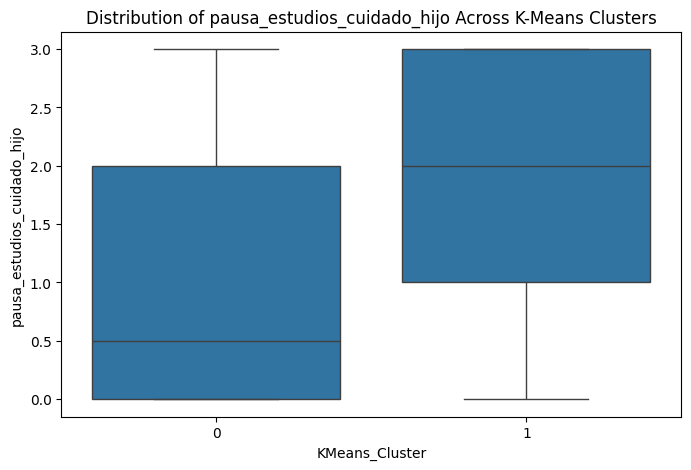

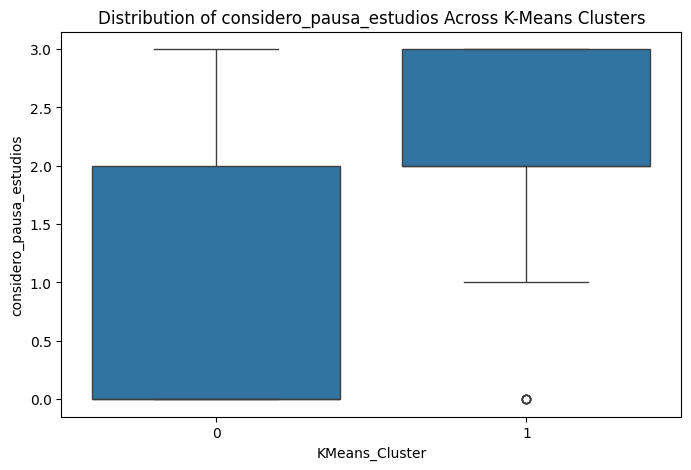

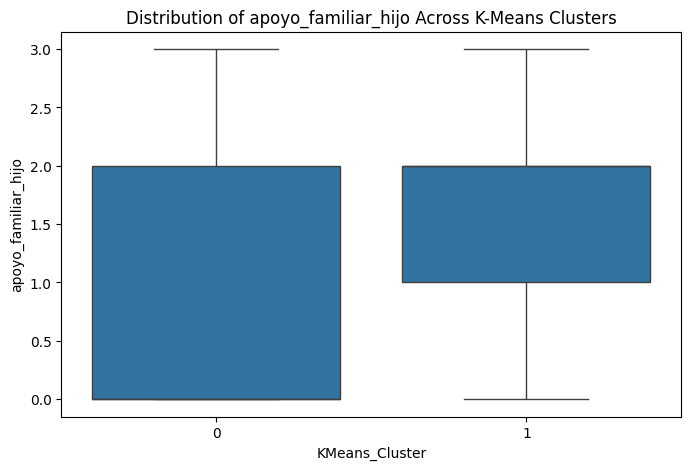

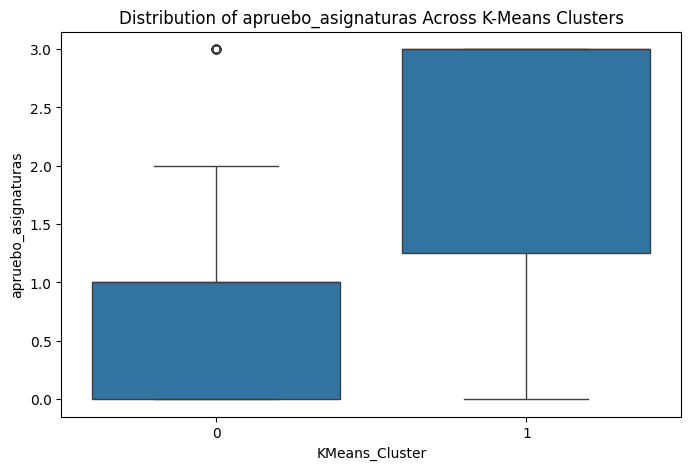

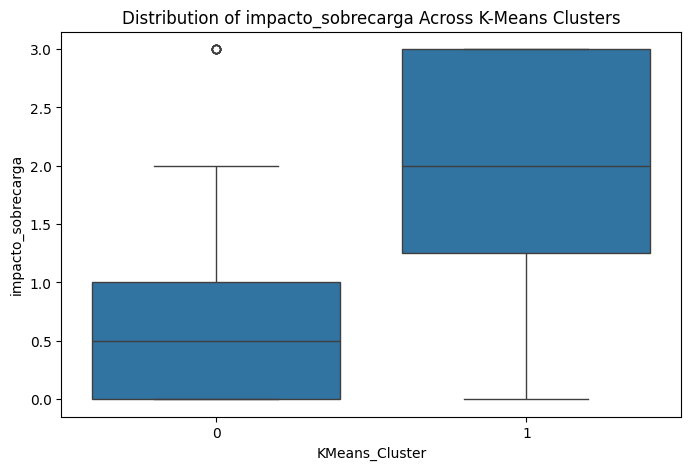

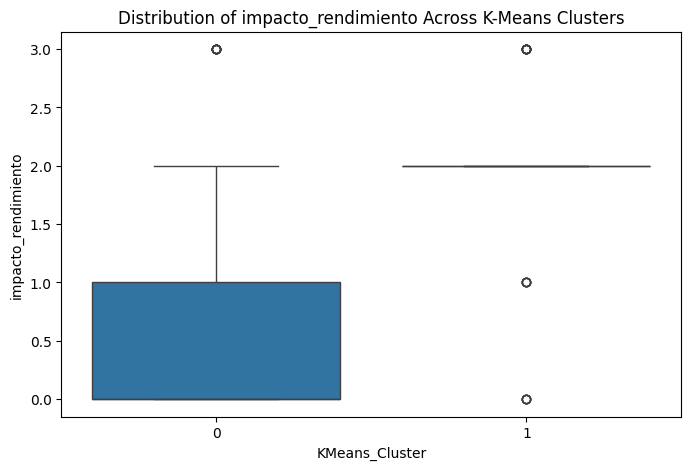

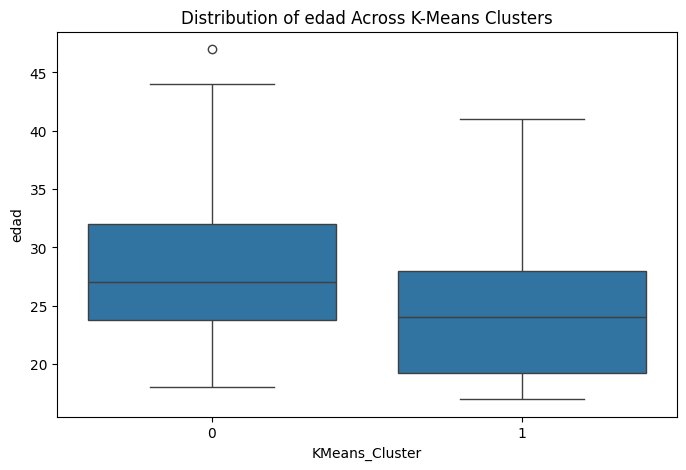

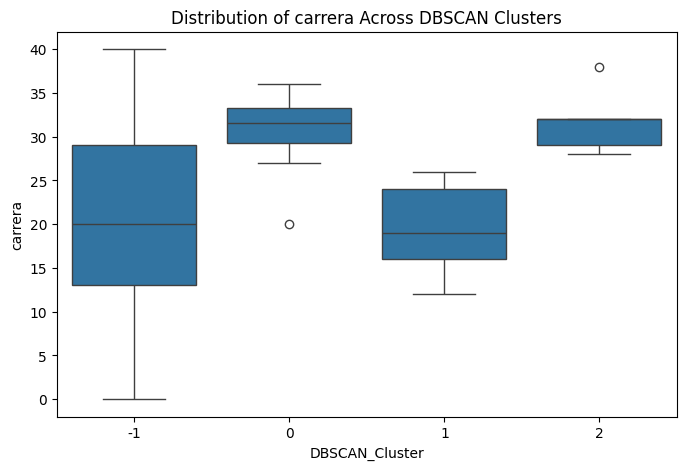

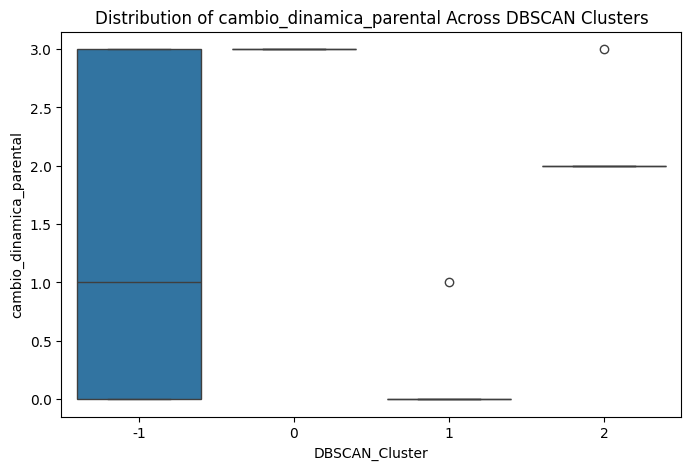

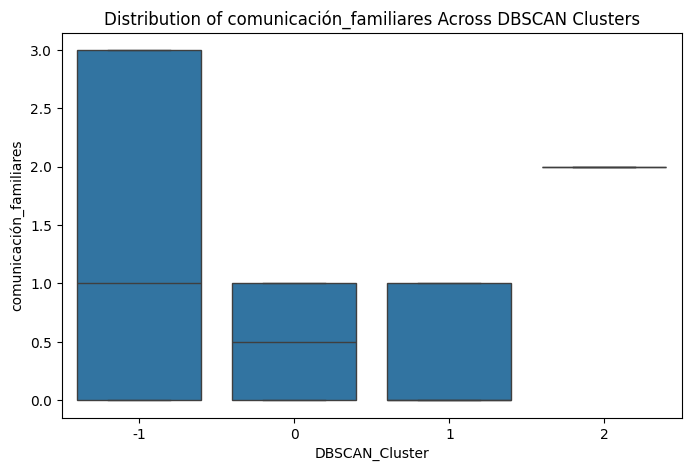

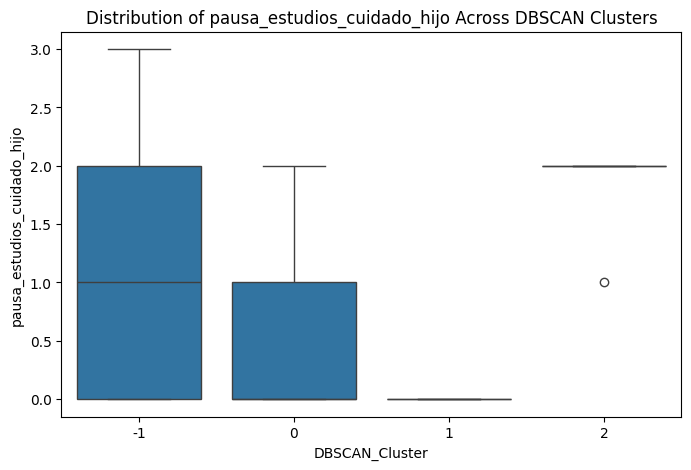

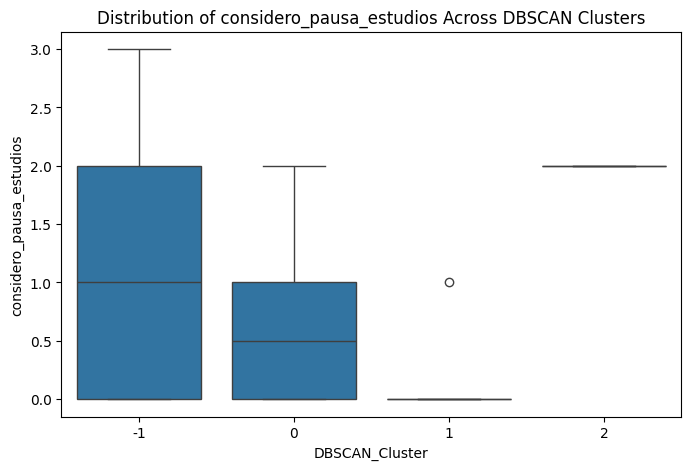

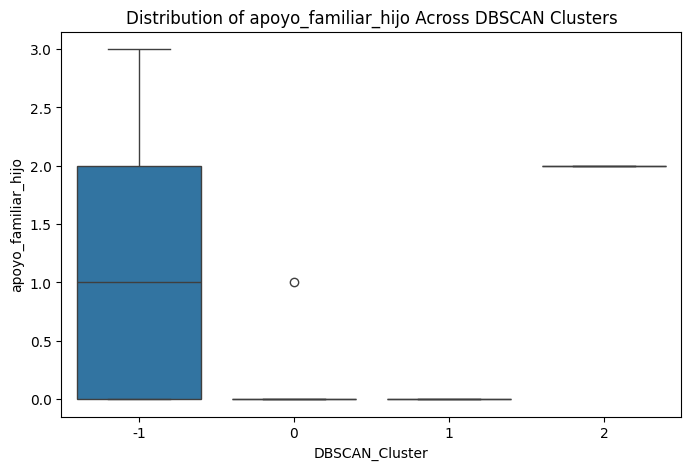

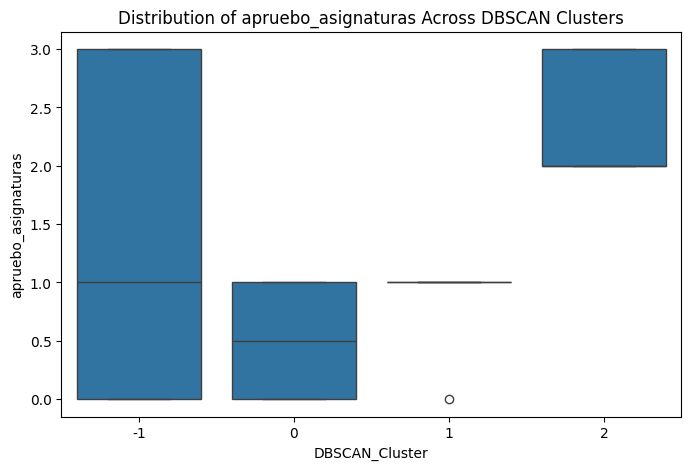

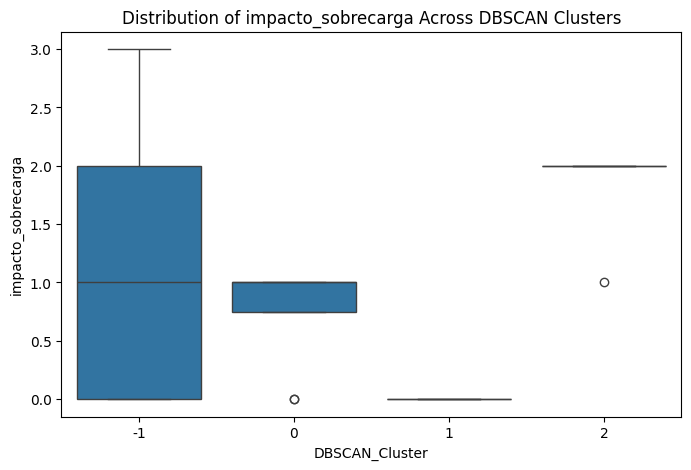

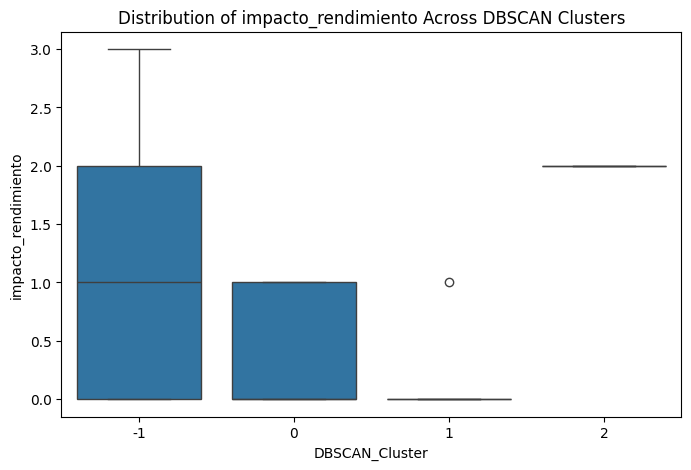

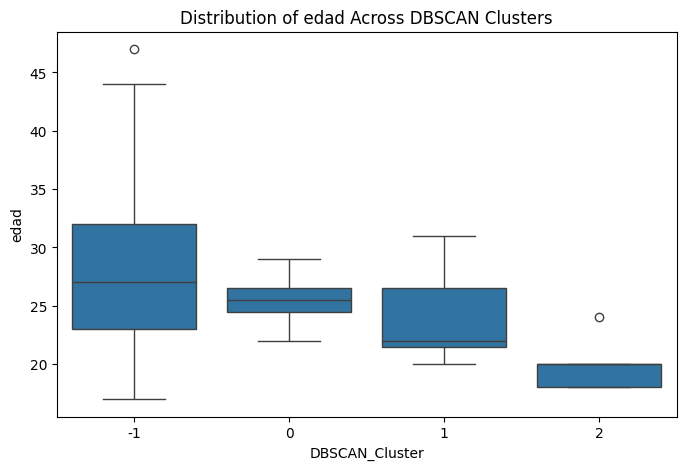

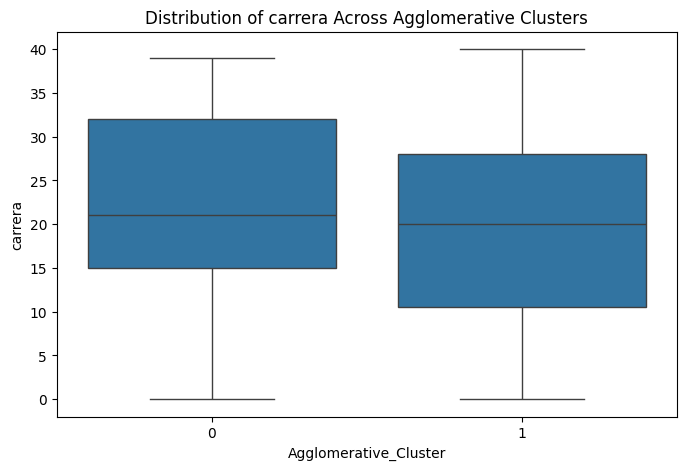

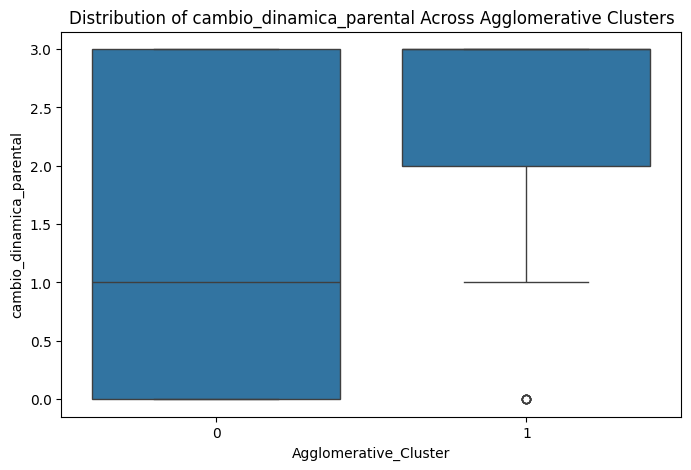

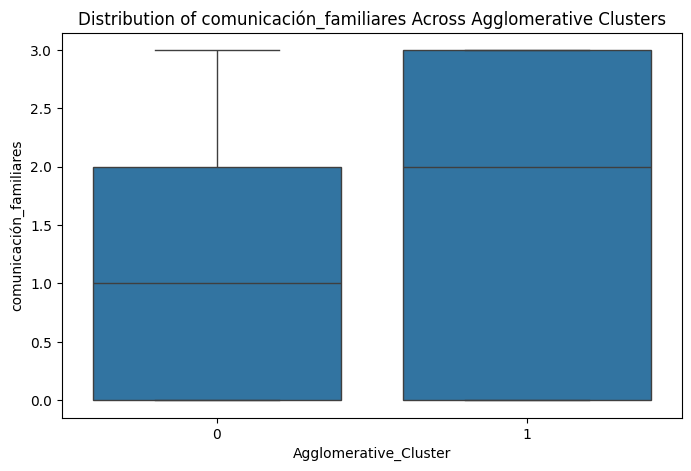

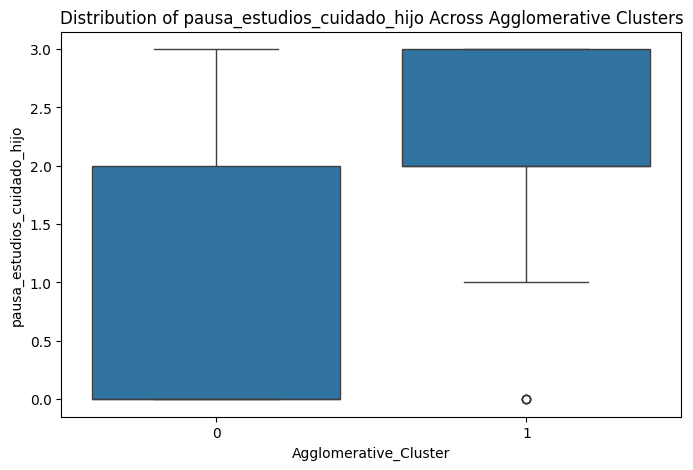

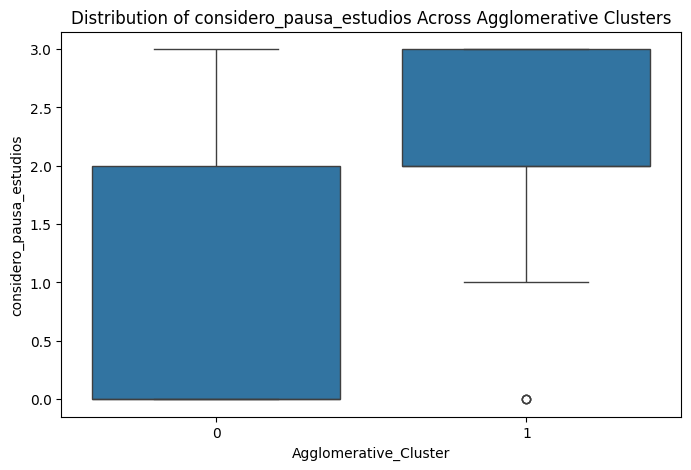

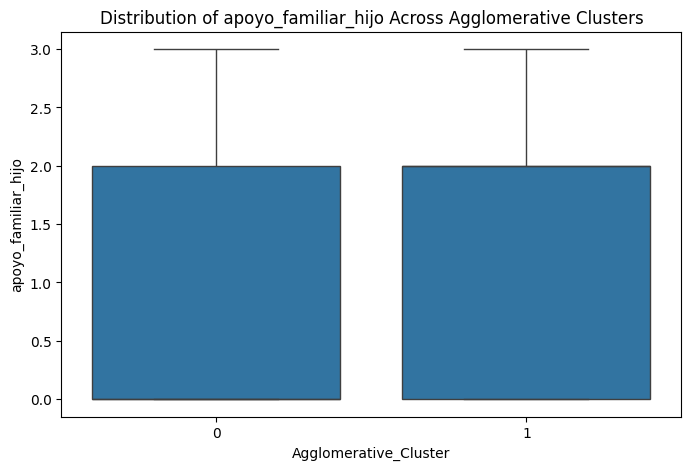

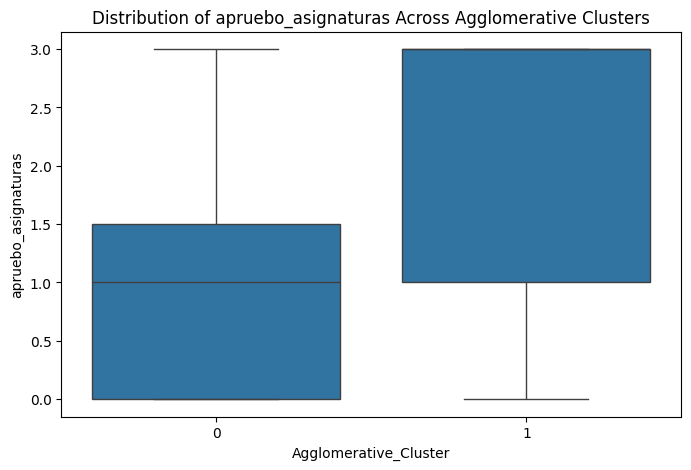

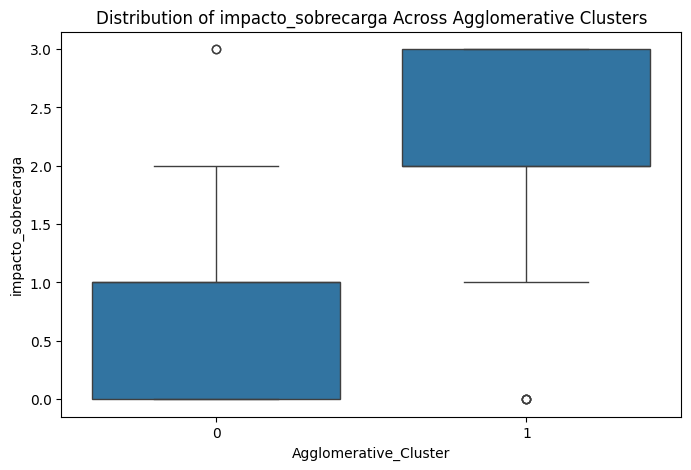

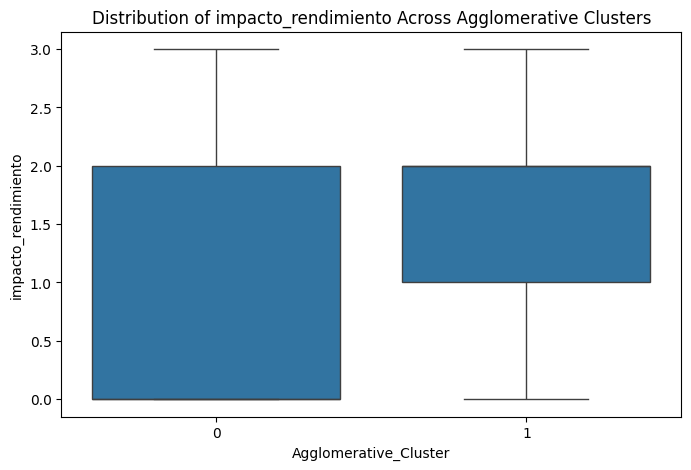

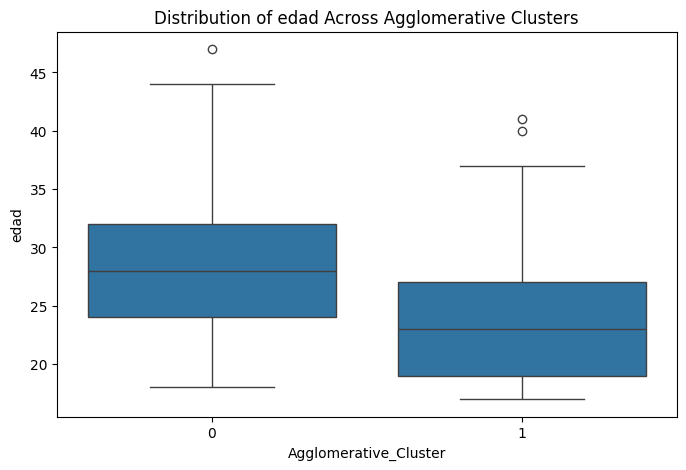

In [ ]:
# Visualize distributions of variables across K-Means clusters
for col in df_cleaned.columns[:-3]:  # Exclude cluster columns
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='KMeans_Cluster', y=col, data=df_cleaned)
    plt.title(f'Distribution of {col} Across K-Means Clusters')
    plt.show()

# Visualize distributions of variables across DBSCAN clusters
if len(set(dbscan_clusters)) > 1:
    for col in df_cleaned.columns[:-3]:  # Exclude cluster columns
        plt.figure(figsize=(8, 5))
        sns.boxplot(x='DBSCAN_Cluster', y=col, data=df_cleaned)
        plt.title(f'Distribution of {col} Across DBSCAN Clusters')
        plt.show()

# Visualize distributions of variables across Agglomerative clusters
for col in df_cleaned.columns[:-3]:  # Exclude cluster columns
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Agglomerative_Cluster', y=col, data=df_cleaned)
    plt.title(f'Distribution of {col} Across Agglomerative Clusters')
    plt.show()

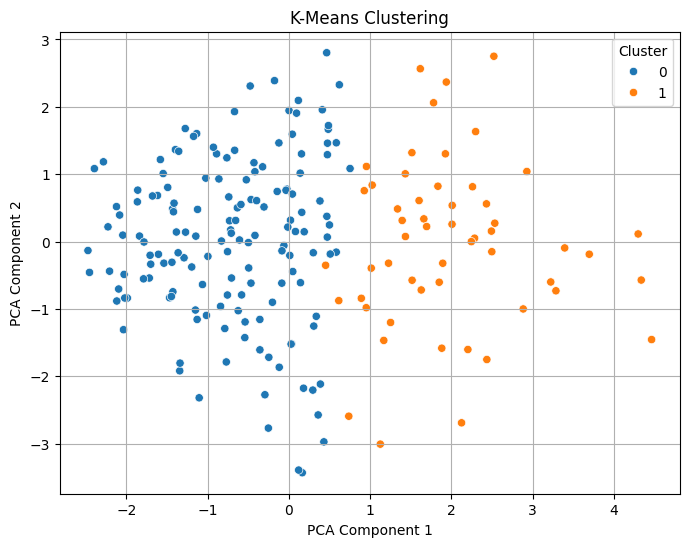

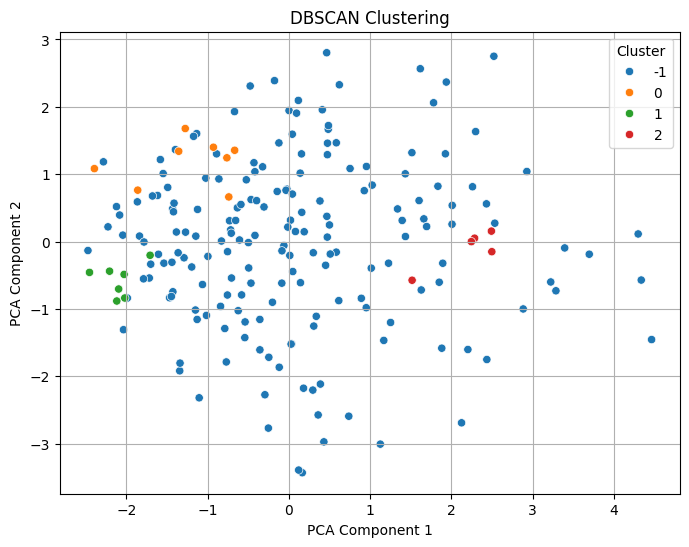

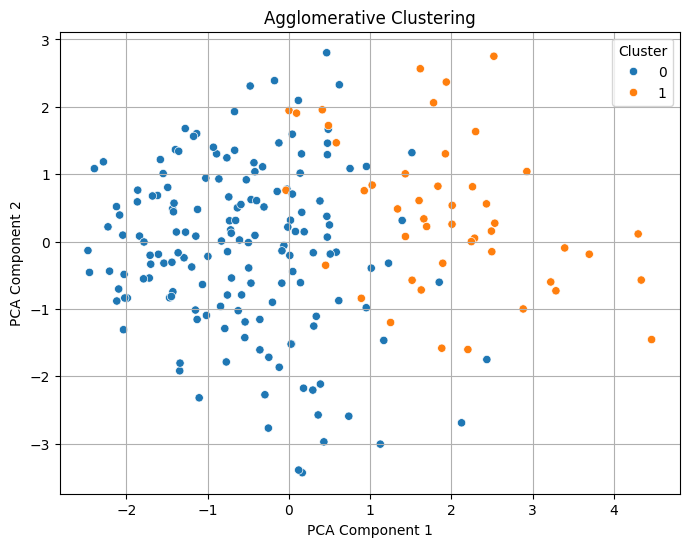

In [ ]:
# Visualize K-Means Clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_reduced[:, 0], y=data_reduced[:, 1], hue=kmeans_clusters, palette='tab10')
plt.title('K-Means Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Visualize DBSCAN Clustering
if len(set(dbscan_clusters)) > 1:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=data_reduced[:, 0], y=data_reduced[:, 1], hue=dbscan_clusters, palette='tab10')
    plt.title('DBSCAN Clustering')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()

# Visualize Agglomerative Clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_reduced[:, 0], y=data_reduced[:, 1], hue=agglo_clusters, palette='tab10')
plt.title('Agglomerative Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [ ]:
# Output results
print("Cluster Distribution:")
print(df_cleaned['KMeans_Cluster'].value_counts())

Cluster Distribution:
KMeans_Cluster
1    122
0     84
Name: count, dtype: int64


In [ ]:
# Statistical correlation analysis
correlation_results = {}
for column in df_cleaned.columns[:-3]:  # Exclude the cluster columns
    if df_cleaned[column].dtype in [np.int64, np.float64]:
        correlation, p_value = spearmanr(df_cleaned[column], df_cleaned['KMeans_Cluster'])
        correlation_results[column] = {'Correlation': correlation, 'P-Value': p_value}

# Display significant correlations
print("Significant Correlations with Clusters:")
for column, stats in correlation_results.items():
    if stats['P-Value'] < 0.05:
        print(f"{column}: Correlation = {stats['Correlation']:.2f}, P-Value = {stats['P-Value']:.4f}")

# Output results
print("K-Means Silhouette Score:", kmeans_silhouette)
print("DBSCAN Silhouette Score:", dbscan_silhouette)
print("Agglomerative Clustering Silhouette Score:", agglo_silhouette)
print("Cluster Distribution:")
print(df_cleaned['KMeans_Cluster'].value_counts())


Significant Correlations with Clusters:
pausa_estudios_cuidado_hijo: Correlation = -0.58, P-Value = 0.0000
considero_pausa_estudios: Correlation = -0.71, P-Value = 0.0000
considero_dejar_estudiar: Correlation = -0.58, P-Value = 0.0000
coparentalidad_cuidado: Correlation = -0.30, P-Value = 0.0000
abandono_clases: Correlation = -0.31, P-Value = 0.0000
impacto_rendimiento: Correlation = -0.52, P-Value = 0.0000
K-Means Silhouette Score: 0.16443376513485827
DBSCAN Silhouette Score: -0.14324296776433681
Agglomerative Clustering Silhouette Score: 0.13415931771807177
Cluster Distribution:
KMeans_Cluster
1    122
0     84
Name: count, dtype: int64
